In [60]:
import numpy as np
import pandas as pd
import math
import json
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy

In [61]:
df = pd.read_csv(r'C:\Users\m.ahmadi\Desktop\FINALPROJECT\docs\g10.csv', low_memory=False)
df.head()

,Id,CreateDate,CreateBy,ModifiedDate,ModifiedBy,Disabled,JobType,AccNumber,DepositNumber,Province,...,BusinessHistoryScore,IranianMinScore,PersonnelScore,Id.2,NationalCode,LoanDetail,ChequeDetail,CreateDate.1,RowVersion.2,rn.1
0,20648056,2025-12-30 18:41:38.340,QBank,2025-12-30 18:46:35.893,Calculate-Engine,0.0,4.0,NaN,7.611025e+17,NaN,...,0.0,100.0,0.0,7212268.0,5.359915e+09,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",2025-12-30 18:46:35.8584810,0x00000000068851E5,1.0
1,19887483,2025-12-10 16:25:40.877,QBank,2025-12-10 19:30:10.757,Calculate-Engine,0.0,0.0,NaN,3.003700e+17,NaN,...,0.0,100.0,0.0,6228812.0,4.900352e+09,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",2025-12-10 19:30:13.8869757,0x000000000607BC5C,1.0
2,19472557,2025-11-29 10:36:02.647,QBank,2025-12-01 12:53:25.090,Calculate-Engine,1.0,1.0,NaN,2.019700e+17,NaN,...,0.0,80.0,0.0,5724763.0,1.378028e+09,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",2025-12-01 12:53:24.9827486,0x0000000005CE48F7,1.0
3,20384234,2025-12-24 17:53:04.550,QBank,2025-12-28 14:28:14.337,Calculate-Engine,0.0,0.0,1.0,5.404700e+17,0.0,...,0.0,40.0,0.0,7075232.0,3.790421e+09,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",2025-12-28 14:28:14.3080392,0x000000000677B8CC,1.0
4,20803666,2026-01-04 18:44:14.037,QBank,2026-01-04 18:50:30.043,Calculate-Engine,0.0,4.0,NaN,2.418700e+17,NaN,...,0.0,100.0,0.0,7380764.0,4.640032e+09,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",2026-01-04 18:50:29.9923928,0x00000000069BF8BD,1.0


 ## Keep usefull cols 

In [62]:
cols_to_keep = [
                "NationalCode", "LoanDetail","ChequeDetail", "JobType", "IranianRank",
                "MountlyIncome", "IncomeScore", "JobScore", "AssetScore",
                "TotalCustomerScore", "TotalFacilities"
]
df1 = df[cols_to_keep]
df1

,NationalCode,LoanDetail,ChequeDetail,JobType,IranianRank,MountlyIncome,IncomeScore,JobScore,AssetScore,TotalCustomerScore,TotalFacilities
0,5.359915e+09,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",4.0,A1,NaN,0.0,0.0,0.0,30.0,0.000000e+00
1,4.900352e+09,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",0.0,A3,550000000.0,54.0,20.0,0.0,82.0,2.460000e+09
2,1.378028e+09,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",1.0,B1,NaN,4.0,18.0,0.0,36.0,3.600000e+08
3,3.790421e+09,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",0.0,D2,100000000.0,4.0,18.0,0.0,35.0,3.500000e+08
4,4.640032e+09,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",4.0,A3,NaN,0.0,0.0,0.0,30.0,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...
99996,1.273084e+09,"{""Data"":{""BadHesabiDate"":null,""Country"":null,""...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",0.0,C1,1.0,4.0,20.0,0.0,33.0,3.300000e+08
99997,1.850282e+09,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",4.0,C1,320000000.0,0.0,0.0,0.0,18.0,0.000000e+00
99998,7.963509e+07,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",0.0,D1,280000000.0,36.0,20.0,0.0,49.0,4.900000e+08
99999,2.803690e+09,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",0.0,B1,300000000.0,36.0,20.0,0.0,58.0,1.160000e+09


In [63]:
cols_to_numeric = ["MountlyIncome", "JobType"]
df1[cols_to_numeric] = df1[cols_to_numeric].apply(pd.to_numeric, errors='coerce')

df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 100001 entries, 0 to 100000
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   NationalCode        100000 non-null  float64
 1   LoanDetail          100000 non-null  str    
 2   ChequeDetail        99999 non-null   str    
 3   JobType             100000 non-null  float64
 4   IranianRank         100000 non-null  str    
 5   MountlyIncome       60119 non-null   float64
 6   IncomeScore         100000 non-null  float64
 7   JobScore            100000 non-null  float64
 8   AssetScore          100000 non-null  float64
 9   TotalCustomerScore  100000 non-null  float64
 10  TotalFacilities     100000 non-null  float64
dtypes: float64(8), str(3)
memory usage: 8.4 MB


## Feature Engineering

In [64]:
def process_data(json_str):

    new_col_names = [  
        'DebtAmount', 'OriginAmount', 'LoanCounts','SarResid', 'Moavagh', 'Mashkuk', 'DefaultFlag', 'DebtRatio', 'DebtPerLoan'
    ]

    try:
        data = json.loads(json_str)
        loan_rows = data.get('Data', {}).get('EstelamAsliRows', [])
        if not loan_rows:
            return pd.Series([0]*len(new_col_names), index=  new_col_names)
        for row in loan_rows:
            for key in ['AmBedehiKol', 'AmOriginal', 'AmSarResid', 'AmMoavagh', 'AmMashkuk']:
                row[key] = float(row.get(key, 0)) if row.get(key) is not None else 0.0

        debt_amount = sum(row["AmBedehiKol"] for row in loan_rows)
        origin_amount = sum(row["AmOriginal"] for row in loan_rows)
        loan_counts = len(loan_rows)

        default_flag = 0
        total_penalty_points= 0
        weighted_penalty_numerator= 0
        defaulted_loans_count = 0
        debt_ratio_list = []


        for row in loan_rows:
            sarresid_val = float(row.get('AmSarResid', 0) or 0)
            moavagh_val = float(row.get('AmMoavagh', 0) or 0)
            mashkuk_val = float(row.get('AmMashkuk', 0) or 0) 

            pi = (1 * sarresid_val) + (3 * moavagh_val) + (60 * mashkuk_val)

            if pi > 0:
                default_flag = 1 
                defaulted_loans_count +=1

            if row['AmOriginal'] > 0:
                debt_ratio_list.append(row['AmBedehiKol']/row['AmOriginal'])

            total_penalty_points+=pi
            weighted_penalty_numerator+= pi*row['AmBedehiKol']


        debt_ratio = np.mean(debt_ratio_list) if debt_ratio_list else 0 
        debt_per_loan = debt_amount/loan_counts if loan_counts > 0 else 0

        return pd.Series([
        debt_amount, origin_amount, loan_counts, sarresid_val, moavagh_val, mashkuk_val, default_flag,
        debt_ratio, debt_per_loan,
    ], index=new_col_names)
    except(json.JSONDecodeError, TypeError, AttributeError):
        return pd.Series([np.nan] * len(new_col_names), index=new_col_names)

In [65]:
new_features = df1['LoanDetail'].apply(process_data)
df_merg = pd.concat([df1, new_features], axis = 1)
df_merg

,NationalCode,LoanDetail,ChequeDetail,JobType,IranianRank,MountlyIncome,IncomeScore,JobScore,AssetScore,TotalCustomerScore,TotalFacilities,DebtAmount,OriginAmount,LoanCounts,SarResid,Moavagh,Mashkuk,DefaultFlag,DebtRatio,DebtPerLoan
0,5.359915e+09,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",4.0,A1,NaN,0.0,0.0,0.0,30.0,0.000000e+00,4.068485e+08,1.150000e+09,2.0,0.0,0.0,0.0,0.0,0.415131,2.034242e+08
1,4.900352e+09,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",0.0,A3,550000000.0,54.0,20.0,0.0,82.0,2.460000e+09,8.992494e+09,9.265000e+09,7.0,0.0,0.0,0.0,0.0,0.930646,1.284642e+09
2,1.378028e+09,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",1.0,B1,NaN,4.0,18.0,0.0,36.0,3.600000e+08,3.949491e+08,7.240734e+08,1.0,0.0,0.0,0.0,0.0,0.545455,3.949491e+08
3,3.790421e+09,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",0.0,D2,100000000.0,4.0,18.0,0.0,35.0,3.500000e+08,5.730941e+08,9.300000e+08,2.0,0.0,0.0,0.0,0.0,0.633785,2.865471e+08
4,4.640032e+09,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",4.0,A3,NaN,0.0,0.0,0.0,30.0,0.000000e+00,8.676012e+08,1.161000e+09,1.0,0.0,0.0,0.0,0.0,0.747288,8.676012e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99996,1.273084e+09,"{""Data"":{""BadHesabiDate"":null,""Country"":null,""...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",0.0,C1,1.0,4.0,20.0,0.0,33.0,3.300000e+08,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000e+00
99997,1.850282e+09,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",4.0,C1,320000000.0,0.0,0.0,0.0,18.0,0.000000e+00,6.224592e+08,1.197000e+09,2.0,0.0,0.0,0.0,0.0,0.590366,3.112296e+08
99998,7.963509e+07,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",0.0,D1,280000000.0,36.0,20.0,0.0,49.0,4.900000e+08,8.885040e+08,1.000000e+09,1.0,0.0,0.0,0.0,0.0,0.888504,8.885040e+08
99999,2.803690e+09,"{""Data"":{""BadHesabiDate"":"""",""Country"":null,""Cu...","{""Data"":{""Cheques"":[],""ErrorList"":[],""IsValid""...",0.0,B1,300000000.0,36.0,20.0,0.0,58.0,1.160000e+09,1.693428e+08,3.000000e+08,1.0,0.0,0.0,0.0,0.0,0.564476,1.693428e+08


In [66]:
pd.to_numeric(df_merg['DefaultFlag'])
print((df_merg[df_merg['DefaultFlag'] == 1]).count())

NationalCode          68
LoanDetail            68
ChequeDetail          68
JobType               68
IranianRank           68
MountlyIncome         61
IncomeScore           68
JobScore              68
AssetScore            68
TotalCustomerScore    68
TotalFacilities       68
DebtAmount            68
OriginAmount          68
LoanCounts            68
SarResid              68
Moavagh               68
Mashkuk               68
DefaultFlag           68
DebtRatio             68
DebtPerLoan           68
dtype: int64


In [67]:
df_merg.drop(columns=['LoanDetail', 'ChequeDetail', 'Mashkuk', 'Moavagh', 'SarResid'], inplace=True)

## Add iranian data

In [68]:
rank_data = {
    'IranianRank': ['A1', 'A2', 'A3', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3', 'D1', 'D2', 'D3', 'E1', 'E2', 'E3', 'Z'],
    'Score_Max': [900, 679, 659, 639, 619, 599, 579, 559, 539, 519, 499, 479, 459, 439, 419, 559],
    'Score_Min': [680, 660, 640, 620, 600, 580, 560, 540, 520, 500, 480, 460, 440, 420, 0, 540],
    'Risk_Max': [3.1, 4.8, 7.5, 11.3, 16.9, 24.4, 33.8, 44.8, 56.3, 67.2, 76.5, 83.8, 89.1, 92.9, 100.0, 33.8],
    'Risk_Min': [0.0, 3.1, 4.8, 7.5, 11.3, 16.9, 24.4, 33.8, 44.8, 56.3, 67.2, 76.5, 83.8, 89.1, 92.9, 24.4],
}
rank_lookup_df = pd.DataFrame(rank_data)

df_merg['Has_No_History'] = np.where(df_merg['IranianRank'] == 'Z', 1, 0)

df_enriched = pd.merge(df_merg, rank_lookup_df, on='IranianRank', how='left')
df_enriched

,NationalCode,JobType,IranianRank,MountlyIncome,IncomeScore,JobScore,AssetScore,TotalCustomerScore,TotalFacilities,DebtAmount,OriginAmount,LoanCounts,DefaultFlag,DebtRatio,DebtPerLoan,Has_No_History,Score_Max,Score_Min,Risk_Max,Risk_Min
0,5.359915e+09,4.0,A1,NaN,0.0,0.0,0.0,30.0,0.000000e+00,4.068485e+08,1.150000e+09,2.0,0.0,0.415131,2.034242e+08,0,900.0,680.0,3.1,0.0
1,4.900352e+09,0.0,A3,550000000.0,54.0,20.0,0.0,82.0,2.460000e+09,8.992494e+09,9.265000e+09,7.0,0.0,0.930646,1.284642e+09,0,659.0,640.0,7.5,4.8
2,1.378028e+09,1.0,B1,NaN,4.0,18.0,0.0,36.0,3.600000e+08,3.949491e+08,7.240734e+08,1.0,0.0,0.545455,3.949491e+08,0,639.0,620.0,11.3,7.5
3,3.790421e+09,0.0,D2,100000000.0,4.0,18.0,0.0,35.0,3.500000e+08,5.730941e+08,9.300000e+08,2.0,0.0,0.633785,2.865471e+08,0,499.0,480.0,76.5,67.2
4,4.640032e+09,4.0,A3,NaN,0.0,0.0,0.0,30.0,0.000000e+00,8.676012e+08,1.161000e+09,1.0,0.0,0.747288,8.676012e+08,0,659.0,640.0,7.5,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99996,1.273084e+09,0.0,C1,1.0,4.0,20.0,0.0,33.0,3.300000e+08,0.000000e+00,0.000000e+00,0.0,0.0,0.000000,0.000000e+00,0,579.0,560.0,33.8,24.4
99997,1.850282e+09,4.0,C1,320000000.0,0.0,0.0,0.0,18.0,0.000000e+00,6.224592e+08,1.197000e+09,2.0,0.0,0.590366,3.112296e+08,0,579.0,560.0,33.8,24.4
99998,7.963509e+07,0.0,D1,280000000.0,36.0,20.0,0.0,49.0,4.900000e+08,8.885040e+08,1.000000e+09,1.0,0.0,0.888504,8.885040e+08,0,519.0,500.0,67.2,56.3
99999,2.803690e+09,0.0,B1,300000000.0,36.0,20.0,0.0,58.0,1.160000e+09,1.693428e+08,3.000000e+08,1.0,0.0,0.564476,1.693428e+08,0,639.0,620.0,11.3,7.5


In [69]:
missing_values = df_enriched.isnull().sum()

missing_percent = (missing_values / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing_Count': missing_values,
    'Missing_Percent': missing_percent
})

missing_info_sorted = missing_info.loc[lambda x: x['Missing_Count'] > 0].sort_values(by='Missing_Percent', ascending=False)

with pd.option_context('display.max_rows', None):
    print(missing_info_sorted)

                    Missing_Count  Missing_Percent
MountlyIncome               39882        39.881601
OriginAmount                    2         0.002000
DebtAmount                      2         0.002000
DebtPerLoan                     2         0.002000
DebtRatio                       2         0.002000
DefaultFlag                     2         0.002000
LoanCounts                      2         0.002000
IranianRank                     1         0.001000
JobType                         1         0.001000
NationalCode                    1         0.001000
IncomeScore                     1         0.001000
TotalCustomerScore              1         0.001000
TotalFacilities                 1         0.001000
JobScore                        1         0.001000
AssetScore                      1         0.001000
Score_Max                       1         0.001000
Score_Min                       1         0.001000
Risk_Max                        1         0.001000
Risk_Min                       

In [70]:
cols_to_drop = ["NationalCode", "IranianRank"]
df_cleaned = df_enriched.drop(columns= cols_to_drop)
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 100001 entries, 0 to 100000
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   JobType             100000 non-null  float64
 1   MountlyIncome       60119 non-null   float64
 2   IncomeScore         100000 non-null  float64
 3   JobScore            100000 non-null  float64
 4   AssetScore          100000 non-null  float64
 5   TotalCustomerScore  100000 non-null  float64
 6   TotalFacilities     100000 non-null  float64
 7   DebtAmount          99999 non-null   float64
 8   OriginAmount        99999 non-null   float64
 9   LoanCounts          99999 non-null   float64
 10  DefaultFlag         99999 non-null   float64
 11  DebtRatio           99999 non-null   float64
 12  DebtPerLoan         99999 non-null   float64
 13  Has_No_History      100001 non-null  int64  
 14  Score_Max           100000 non-null  float64
 15  Score_Min           100000 non-null  float64


In [71]:
df_cleaned["MountlyIncome"] = df_cleaned["MountlyIncome"].fillna(0, inplace=True)
df_cleaned["Employed"] = np.where(df_cleaned["JobType"] == 4 , 0, 1)

C:\Users\m.ahmadi\AppData\Local\Temp\ipykernel_24836\1460014506.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_cleaned["MountlyIncome"] = df_cleaned["MountlyIncome"].fillna(0, inplace=True)


In [72]:
df_cleaned

,JobType,MountlyIncome,IncomeScore,JobScore,AssetScore,TotalCustomerScore,TotalFacilities,DebtAmount,OriginAmount,LoanCounts,DefaultFlag,DebtRatio,DebtPerLoan,Has_No_History,Score_Max,Score_Min,Risk_Max,Risk_Min,Employed
0,4.0,0.0,0.0,0.0,0.0,30.0,0.000000e+00,4.068485e+08,1.150000e+09,2.0,0.0,0.415131,2.034242e+08,0,900.0,680.0,3.1,0.0,0
1,0.0,550000000.0,54.0,20.0,0.0,82.0,2.460000e+09,8.992494e+09,9.265000e+09,7.0,0.0,0.930646,1.284642e+09,0,659.0,640.0,7.5,4.8,1
2,1.0,0.0,4.0,18.0,0.0,36.0,3.600000e+08,3.949491e+08,7.240734e+08,1.0,0.0,0.545455,3.949491e+08,0,639.0,620.0,11.3,7.5,1
3,0.0,100000000.0,4.0,18.0,0.0,35.0,3.500000e+08,5.730941e+08,9.300000e+08,2.0,0.0,0.633785,2.865471e+08,0,499.0,480.0,76.5,67.2,1
4,4.0,0.0,0.0,0.0,0.0,30.0,0.000000e+00,8.676012e+08,1.161000e+09,1.0,0.0,0.747288,8.676012e+08,0,659.0,640.0,7.5,4.8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99996,0.0,1.0,4.0,20.0,0.0,33.0,3.300000e+08,0.000000e+00,0.000000e+00,0.0,0.0,0.000000,0.000000e+00,0,579.0,560.0,33.8,24.4,1
99997,4.0,320000000.0,0.0,0.0,0.0,18.0,0.000000e+00,6.224592e+08,1.197000e+09,2.0,0.0,0.590366,3.112296e+08,0,579.0,560.0,33.8,24.4,0
99998,0.0,280000000.0,36.0,20.0,0.0,49.0,4.900000e+08,8.885040e+08,1.000000e+09,1.0,0.0,0.888504,8.885040e+08,0,519.0,500.0,67.2,56.3,1
99999,0.0,300000000.0,36.0,20.0,0.0,58.0,1.160000e+09,1.693428e+08,3.000000e+08,1.0,0.0,0.564476,1.693428e+08,0,639.0,620.0,11.3,7.5,1


In [73]:
df_cleaned.describe()

,JobType,MountlyIncome,IncomeScore,JobScore,AssetScore,TotalCustomerScore,TotalFacilities,DebtAmount,OriginAmount,LoanCounts,DefaultFlag,DebtRatio,DebtPerLoan,Has_No_History,Score_Max,Score_Min,Risk_Max,Risk_Min,Employed
count,100000.000000,1.000010e+05,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,9.999900e+04,9.999900e+04,99999.000000,99999.000000,9.999900e+04,9.999900e+04,100001.000000,100000.000000,100000.000000,100000.000000,100000.000000,100001.000000
mean,1.739800,2.358341e+08,17.616590,11.813980,3.617300,42.690530,7.669832e+08,2.345818e+09,3.147887e+09,2.500175,0.000680,1.809510e+04,6.489337e+08,0.115059,610.479670,557.953000,31.201578,24.467108,0.614824
std,1.860331,5.485910e+09,19.851939,9.381876,7.281557,24.307746,9.142187e+08,8.542601e+10,1.179153e+11,2.751888,0.026068,1.162761e+06,8.681315e+09,0.319095,106.093847,132.501764,26.216417,24.173864,0.486639
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,6.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,419.000000,0.000000,3.100000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000,0.000000,0.000000,24.000000,0.000000e+00,2.038071e+07,1.000000e+08,1.000000,0.000000,9.090479e-02,1.818032e+07,0.000000,559.000000,540.000000,7.500000,4.800000,0.000000
50%,1.000000,1.300000e+08,4.000000,18.000000,0.000000,41.000000,4.100000e+08,7.680712e+08,1.299936e+09,2.000000,0.000000,5.651231e-01,3.220488e+08,0.000000,599.000000,580.000000,24.400000,16.900000,1.000000
75%,4.000000,3.000000e+08,36.000000,20.000000,0.000000,64.000000,1.280000e+09,2.383589e+09,3.200000e+09,4.000000,0.000000,7.777206e-01,7.664405e+08,0.000000,659.000000,640.000000,44.800000,33.800000,1.000000
max,4.000000,8.500000e+11,60.000000,20.000000,20.000000,100.000000,4.000000e+09,1.957363e+13,2.811996e+13,50.000000,1.000000,1.782671e+08,2.446704e+12,1.000000,900.000000,680.000000,100.000000,92.900000,1.000000


### Biulding new features

In [74]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 100001 entries, 0 to 100000
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   JobType             100000 non-null  float64
 1   MountlyIncome       100001 non-null  float64
 2   IncomeScore         100000 non-null  float64
 3   JobScore            100000 non-null  float64
 4   AssetScore          100000 non-null  float64
 5   TotalCustomerScore  100000 non-null  float64
 6   TotalFacilities     100000 non-null  float64
 7   DebtAmount          99999 non-null   float64
 8   OriginAmount        99999 non-null   float64
 9   LoanCounts          99999 non-null   float64
 10  DefaultFlag         99999 non-null   float64
 11  DebtRatio           99999 non-null   float64
 12  DebtPerLoan         99999 non-null   float64
 13  Has_No_History      100001 non-null  int64  
 14  Score_Max           100000 non-null  float64
 15  Score_Min           100000 non-null  float64


### Some Changes

In [75]:
df_cleaned['is_zero_profile'] = ((df_cleaned['MountlyIncome'] == 0) & 
                           (df_cleaned['JobScore'] == 0) & 
                           (df_cleaned['Employed'] == 0) & 
                           (df_cleaned['JobType'] == 4.0)).astype(int)

In [76]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['JobType'], prefix='JobType')
df_cleaned.shape

(100001, 23)

In [77]:
# ۱. تبدیل تمام مقادیر بی‌نهایت به NaN
df_cleaned = df_cleaned.replace([np.inf, -np.inf], np.nan)

# ۲. پر کردن تمام مقادیر NaN (چه در ویژگی‌ها و چه در ستون‌های هدف مثل Default) با صفر
df_cleaned = df_cleaned.fillna(0)
  
# ۳. یک تست برای اطمینان (خروجی باید دقیقاً 0 باشد)
print("تعداد مقادیر خالی در کل دیتاست:", df_cleaned.isna().sum().sum())

تعداد مقادیر خالی در کل دیتاست: 0


In [78]:
# df_cleaned.to_csv("df_cleaned.csv")

In [79]:
df_cleaned["MountlyIncome"].describe()

count    1.000010e+05
mean     2.358341e+08
std      5.485910e+09
min      0.000000e+00
25%      0.000000e+00
50%      1.300000e+08
75%      3.000000e+08
max      8.500000e+11
Name: MountlyIncome, dtype: float64

In [80]:
(df_cleaned["MountlyIncome"] == 0).mean()

np.float64(0.4022059779402206)

### Normalization

In [81]:
raw_incomes_array = df_cleaned['MountlyIncome'].values
raw_incomes_array

array([0.0e+00, 5.5e+08, 0.0e+00, ..., 2.8e+08, 3.0e+08, 3.2e+07],
      shape=(100001,))

In [82]:
raw_debts_array = df_cleaned['DebtAmount'].values
raw_debts_array

array([4.06848487e+08, 8.99249354e+09, 3.94949134e+08, ...,
       8.88504000e+08, 1.69342752e+08, 6.57889468e+09], shape=(100001,))

In [83]:
# reward_data = df_cleaned['DefaultFlag'].copy()
# df_features = df_cleaned.drop(columns=['DefaultFlag']).copy()
df_features = df_cleaned.copy()

binary_features = [col for col in df_features.columns if df_features[col].nunique() == 2]
continuous_cols = [col for col in df_features.columns if col not in binary_features]

scaler = StandardScaler()
df_continuous_scaled = pd.DataFrame(
    scaler.fit_transform(df_features[continuous_cols]), 
    columns=continuous_cols,
    index=df_features.index
)

df_final = pd.concat([df_continuous_scaled, df_features[binary_features]], axis=1)

In [84]:
df_final

,MountlyIncome,IncomeScore,JobScore,AssetScore,TotalCustomerScore,TotalFacilities,DebtAmount,OriginAmount,LoanCounts,DebtRatio,...,Risk_Max,Risk_Min,DefaultFlag,Has_No_History,Employed,is_zero_profile,JobType_0.0,JobType_1.0,JobType_2.0,JobType_4.0
0,-0.042989,-0.887395,-1.259224,-0.496775,-0.522057,-0.838946,-0.022697,-0.016943,-0.181740,-0.015562,...,-1.071899,-1.012125,0.0,0,0,1,False,False,False,True
1,0.057268,1.832758,0.872550,-0.496775,1.617167,1.851893,0.077808,0.051879,1.635206,-0.015561,...,-0.904065,-0.813563,0.0,0,1,0,True,False,False,False
2,-0.042989,-0.685903,0.659372,-0.496775,-0.275224,-0.445165,-0.022837,-0.020555,-0.545129,-0.015562,...,-0.759117,-0.701871,0.0,0,1,0,False,True,False,False
3,-0.024761,-0.685903,0.659372,-0.496775,-0.316363,-0.456103,-0.020751,-0.018809,-0.181740,-0.015562,...,1.727882,1.767750,0.0,0,1,0,True,False,False,False
4,-0.042989,-0.887395,-1.259224,-0.496775,-0.522057,-0.838946,-0.017304,-0.016850,-0.545129,-0.015561,...,-0.904065,-0.813563,0.0,0,0,1,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99996,-0.042989,-0.685903,0.872550,-0.496775,-0.398640,-0.477980,-0.027460,-0.026696,-0.908519,-0.015562,...,0.099126,-0.002766,0.0,0,1,0,True,False,False,False
99997,0.015342,-0.887395,-1.259224,-0.496775,-1.015724,-0.838946,-0.020173,-0.016545,-0.181740,-0.015562,...,0.099126,-0.002766,0.0,0,0,0,False,False,False,True
99998,0.008051,0.926040,0.872550,-0.496775,0.259582,-0.302966,-0.017059,-0.018215,-0.545129,-0.015561,...,1.373141,1.316847,0.0,0,1,0,True,False,False,False
99999,0.011697,0.926040,0.872550,-0.496775,0.629833,0.429905,-0.025478,-0.024152,-0.545129,-0.015562,...,-0.759117,-0.701871,0.0,0,1,0,True,False,False,False


In [85]:
df_cleaned[["MountlyIncome", "TotalCustomerScore", "DebtAmount", "DebtRatio", "Score_Min", "Score_Max"]].describe()

,MountlyIncome,TotalCustomerScore,DebtAmount,DebtRatio,Score_Min,Score_Max
count,1.000010e+05,100001.000000,1.000010e+05,1.000010e+05,100001.000000,100001.000000
mean,2.358341e+08,42.690103,2.345771e+09,1.809474e+04,557.947421,610.473565
std,5.485910e+09,24.308000,8.542515e+10,1.162750e+06,132.512848,106.110879
min,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,0.000000e+00,24.000000,2.038000e+07,9.090157e-02,540.000000,559.000000
50%,1.300000e+08,41.000000,7.680712e+08,5.651221e-01,580.000000,599.000000
75%,3.000000e+08,64.000000,2.383525e+09,7.777149e-01,640.000000,659.000000
max,8.500000e+11,100.000000,1.957363e+13,1.782671e+08,680.000000,900.000000


In [86]:
exposure = (
    df_cleaned["TotalFacilities"] /
    (df_cleaned["OriginAmount"] + 1)
)

exposure.describe()

count    1.000010e+05
mean     5.525436e+07
std      2.556309e+08
min      0.000000e+00
25%      0.000000e+00
50%      1.560598e-01
75%      7.774860e-01
max      3.800000e+09
dtype: float64

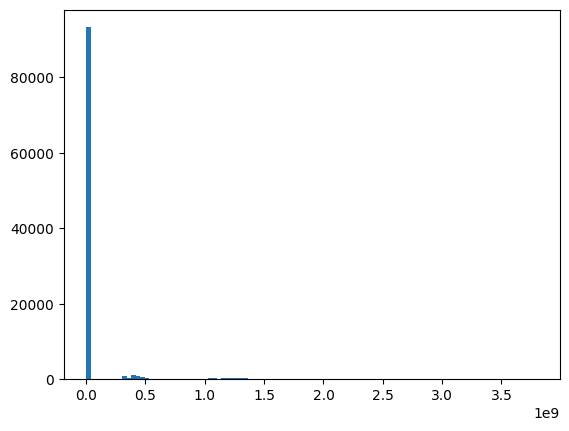

In [87]:
import matplotlib.pyplot as plt

plt.hist(exposure, bins=100)
plt.show()

In [88]:
df_final.describe()

,MountlyIncome,IncomeScore,JobScore,AssetScore,TotalCustomerScore,TotalFacilities,DebtAmount,OriginAmount,LoanCounts,DebtRatio,DebtPerLoan,Score_Max,Score_Min,Risk_Max,Risk_Min,DefaultFlag,Has_No_History,Employed,is_zero_profile
count,1.000010e+05,1.000010e+05,1.000010e+05,1.000010e+05,1.000010e+05,1.000010e+05,1.000010e+05,1.000010e+05,1.000010e+05,1.000010e+05,1.000010e+05,1.000010e+05,1.000010e+05,1.000010e+05,1.000010e+05,100001.000000,100001.000000,100001.000000,100001.000000
mean,1.705286e-18,-6.202976e-17,-3.637942e-17,-5.741128e-17,-4.050053e-17,-5.158489e-17,-5.684285e-19,-5.684285e-19,1.563178e-17,-5.684285e-19,3.979000e-18,-1.485019e-16,-1.912051e-16,2.010816e-17,-1.034540e-16,0.000680,0.115059,0.614824,0.345867
std,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,0.026068,0.319095,0.486639,0.475652
min,-4.298927e-02,-8.873955e-01,-1.259224e+00,-4.967750e-01,-1.756225e+00,-8.389464e-01,-2.746009e-02,-2.669605e-02,-9.085187e-01,-1.556211e-02,-7.475025e-02,-5.753195e+00,-4.210537e+00,-1.190146e+00,-1.012125e+00,0.000000,0.000000,0.000000,0.000000
25%,-4.298927e-02,-8.873955e-01,-1.259224e+00,-4.967750e-01,-7.688908e-01,-8.389464e-01,-2.722152e-02,-2.584797e-02,-5.451294e-01,-1.556203e-02,-7.265606e-02,-4.850947e-01,-1.354398e-01,-9.040646e-01,-8.135629e-01,0.000000,0.000000,0.000000,0.000000
50%,-1.929208e-02,-6.859026e-01,6.593725e-01,-4.967750e-01,-6.952903e-02,-3.904731e-01,-1.846889e-02,-1.567187e-02,-1.817401e-01,-1.556162e-02,-3.765339e-02,-1.081286e-01,1.664193e-01,-2.594285e-01,-3.130199e-01,0.000000,0.000000,1.000000,0.000000
75%,1.169656e-02,9.260404e-01,8.725499e-01,-4.967750e-01,8.766663e-01,5.611653e-01,4.419605e-04,4.424913e-04,5.450385e-01,-1.556144e-02,1.353719e-02,4.573205e-01,6.192078e-01,5.187121e-01,3.860857e-01,0.000000,0.000000,1.000000,1.000000
max,1.549002e+02,2.134998e+00,8.725499e-01,2.249914e+00,2.357668e+00,3.536403e+00,2.291056e+02,2.384529e+02,1.726095e+01,1.533004e+02,2.817651e+02,2.728541e+00,9.210668e-01,2.624269e+00,2.830887e+00,1.000000,1.000000,1.000000,1.000000


In [89]:
# df_final.to_csv('df_final.csv')

### CustomerSimulation

### Build MDP model

### DQN

### PPO